### Example for rpy2:

`%%R -i df -o new_df -w 5 -h 5 --units in -r 200`

- import df from global environment (e.g. `df = pd.DataFrame({...})`)

- make default figure size 5 by 5 inches with 200 dpi resolution
- outputs a new variable `new_df` to python

In [1]:
%load_ext rpy2.ipython

## Explore Dorothea dataset:

In [2]:
%%R
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install("dorothea")

Update all/some/none? [a/s/n]: Bioconductor version 3.18 (BiocManager 1.30.27), R 4.3.3 (2024-02-29)
Bioconductor version '3.18' is out-of-date; the current release version '3.22'
  is available with R version '4.5'; see https://bioconductor.org/install
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cloud.r-project.org
Bioconductor version 3.18 (BiocManager 1.30.27), R 4.3.3 (2024-02-29)
Installation paths not writeable, unable to update packages
  path: /usr/lib/R/library
  packages:
    boot, class, cluster, codetools, foreign, KernSmooth, lattice, nlme, nnet,
    spatial, survival
Old packages: 'cli', 'cpp11', 'devtools', 'dplyr', 'ellipsis', 'fs', 'GenSA',
  'GlobalOptions', 'igraph', 'lazyeval', 'magrittr', 'pak', 'pkgload',
  'processx', 'progressr', 'ps', 'renv', 'reticulate', 'rlang', 'rmarkdown',
  'rpart', 'rsconnect', 'sourcetools', 'this.path', 'ti

RInterpreterError: Failed to parse and evaluate line 'if (!require("BiocManager", quietly = TRUE))\n    install.packages("BiocManager")\n\nBiocManager::install("dorothea")\n'.
R error message: 'Error in if (answer %in% allowed) break : argument is of length zero'
R stdout:
Bioconductor version 3.18 (BiocManager 1.30.27), R 4.3.3 (2024-02-29)
Bioconductor version '3.18' is out-of-date; the current release version '3.22'
  is available with R version '4.5'; see https://bioconductor.org/install
'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cloud.r-project.org
Bioconductor version 3.18 (BiocManager 1.30.27), R 4.3.3 (2024-02-29)
Installation paths not writeable, unable to update packages
  path: /usr/lib/R/library
  packages:
    boot, class, cluster, codetools, foreign, KernSmooth, lattice, nlme, nnet,
    spatial, survival
Old packages: 'cli', 'cpp11', 'devtool

In [ ]:
%%R
library(dorothea)
library(decoupleR)
library(tidyverse)

load("Data/Dorothea/dorothea_hs.rda") # Downloaded from https://github.com/saezlab/dorothea/blob/master/data/dorothea_hs.rda
# The built-in method get_dorothea() does not work

dorothea_filtered <- dorothea_hs %>% filter(confidence %in% c("A","B","C"))
print(dim(dorothea_hs))
print(dim(dorothea_filtered))
# Only filtering by quality ABC reduces no. of edges from 454504 to 13223
# This might be ok, because it lowers computing time (use ABC at least for trial run)

reg_edges = dim(filter(dorothea_filtered,mor==-1))[1]
act_edges = dim(filter(dorothea_filtered,mor==1))[1]
print(reg_edges/(reg_edges+act_edges)) # 15% of interactions are inhibiting

print(length(unique(dorothea_filtered$tf)))
print(length(unique(c(dorothea_filtered$tf,dorothea_filtered$target))))
# ABC has 271 TFs and 5388 genes in total
# It might be important to determine how many of the top 5k differential genes for each perturbation are among these
# If on average only few genes are shared, ABC might not be the best option

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
[1] 454504      4
[1] 13223     4
[1] 0.1550329
[1] 271
[1] 5388



Attaching package: ‘decoupleR’

The following object is masked from ‘package:dorothea’:

    run_viper

In addition: Warning message:
In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :
  libraries ‘/usr/local/lib/R/site-library’, ‘/usr/lib/R/site-library’ contain no packages


## Compare Dorothea to Adamson:

In [ ]:
import anndata as ad
import scanpy as sc
import pandas as pd
import hdf5plugin
import numpy as np

In [2]:
adamson_norm_data = ad.read_h5ad("Data/AdamsonWeissman2016_GSM2406681_10X010/perturb_norm.h5ad")
norman_norm_data = ad.read_h5ad("Data/NormanWeissman2019_filtered/perturb_norm.h5ad")

In [3]:
replogle_norm = ad.read_h5ad("Data/Experimental/ReplogleWeissman2022_K562_essential/perturb_norm.h5ad")

In [15]:
norman_norm = ad.read_h5ad("Data/Experimental/NormanWeissman2019_filtered/perturb_norm.h5ad")

In [58]:
adamson_norm = ad.read_h5ad("Data/Experimental/AdamsonWeissman2016_GSM2406681_10X010/perturb_norm.h5ad")

In [112]:
replogle_norm

AnnData object with n_obs × n_vars = 33752 × 8563
    obs: 'batch', 'gene', 'gene_id', 'transcript', 'gene_transcript', 'guide_id', 'percent_mito', 'UMI_count', 'z_gemgroup_UMI', 'core_scale_factor', 'core_adjusted_UMI_count', 'disease', 'cancer', 'cell_line', 'sex', 'age', 'perturbation', 'organism', 'perturbation_type', 'tissue_type', 'ncounts', 'ngenes', 'nperts', 'percent_ribo', 'cell_type', 'condition', 'condition_name', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier'
    var: 'chr', 'start', 'end', 'class', 'strand', 'length', 'in_matrix', 'mean', 'std', 'cv', 'fano', 'ensembl_id', 'ncounts', 'ncells', 'gene_name', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_

In [60]:
norman_perts = set(list(norman_norm.obs["perturbation"]))
replogle_perts = set(list(replogle_norm.obs["perturbation"]))
adamson_perts = set(list(adamson_norm.obs["perturbation"]))

In [16]:
doro_df = pd.read_csv("Data/dorothea_abcd.topo",sep=" ")
doro_tfs = set(list(doro_df["Source"]))

In [68]:
doro_genes = set(doro_df["Source"]) | set(doro_df["Target"])
len(set(doro_df["Source"]))

361

In [20]:
keggoro_abcd = pd.read_csv("Data/Keggoro_abcd/Keggoro_abcd.topo",sep=" ")
keggoro_tfs = set(list(keggoro_abcd["Source"]))

In [27]:
kegg = pd.read_csv("Data/Topos/kegg.topo",sep=" ")
kegg_tfs = set(list(kegg["Source"]))

In [ ]:
for ex in [adamson_perts,norman_perts,replogle_perts]:
    for grn in [doro_tfs,kegg_tfs,keggoro_tfs]:
        print(len(ex & grn))

2
10
10
22
28
39
10
53
61


In [76]:
len(set(doro_df["Source"])|set(doro_df["Target"]))

9917

In [85]:
keggoro_full = pd.concat([doro_df,kegg]).drop_duplicates()
len(set(keggoro_full["Source"])|set(keggoro_full["Target"]))

10642

In [92]:
a = list(set(keggoro_abcd[keggoro_abcd["Source"].isin(list(keggoro_tfs & norman_perts))]["Target"]))

In [96]:
b = list(set(keggoro_abcd[keggoro_abcd["Source"].isin(a)]["Target"]))

In [97]:
len(set(a) & set(b))

1078

In [ ]:
add_genes = list(keggoro_tfs & norman_perts)
total_add_genes = add_genes
total_add_edges = []
k=2
for i in range(k):
    new_add_edges = keggoro_abcd[keggoro_abcd["Source"].isin(add_genes)]
    total_add_edges.append(new_add_edges)
    new_add_genes = list(set(list(new_add_edges["Target"])))
    total_add_genes = list(set(total_add_genes+new_add_genes))
    print(f"for i={i}, {len(new_add_genes)} genes along {len(new_add_edges)} edges have been found")
    add_genes = new_add_genes
    
keggoro_d2 = pd.concat(total_add_edges).drop_duplicates().sort_values(by=["Source","Target"])
keggoro_d2.to_csv("Data/Topos/Keggoro_abcd_d2.topo",index=False,sep=" ")

for i=0, 1287 genes along 1673 edges have been found
for i=1, 3995 genes along 8689 edges have been found


In [106]:
len(set(list(keggoro_d2["Source"])))

472

### Normalize Adamson:
- Note: code not updated for reduction of Adamson to 5k variable genes

In [4]:
print(adamson_norm_data.X.shape,adamson_norm_data.layers["log1p"].shape)
adamson_norm_data = adamson_norm_data[:,["." not in gene for gene in list(adamson_norm_data.var.index)]]
print(adamson_norm_data.X.shape,adamson_norm_data.layers["log1p"].shape)
mets = sc.pp.highly_variable_genes(adamson_norm_data,n_top_genes=5000, subset=False,inplace=False,layer="log1p")
#sc.pp.highly_variable_genes(adamson_norm_data,n_top_genes=5000, subset=True,inplace=True,layer="log1p")
adamson_all_var_genes = (mets[~mets["dispersions_norm"].isna()]).sort_values(by="dispersions_norm",ascending=False)[:5000].index
adamson_var_genes = set(adamson_all_var_genes)
print(adamson_norm_data.X.shape,adamson_norm_data.layers["log1p"].shape)
adamson_perts = set([p.split("_")[0] for p in adamson_norm_data.obs["perturbation"]])
adamson_all_genes = set(adamson_norm_data.var.index)

(58997, 5000) (58997, 5000)
(58997, 3667) (58997, 3667)
(58997, 3667) (58997, 3667)


### Iterate over Dorothea files:

In [5]:
confidences = ["abcde","abc","abcd"]#,"abcd","abcde"]
for c in confidences:
    doro = pd.read_csv(f"Data/Dorothea/dorothea_{c}.topo",sep=" ")
    doro_genes = set(list(doro["Source"])+list(doro["Target"]))
    doro_tfs = set(list(doro["Source"]))

    """
    Number of common genes between the Adamson 5k var_genes/perturbation and the Dorothea genes
    """
    common_var_genes = len(doro_genes & adamson_var_genes)
    print(f"{common_var_genes} variable genes in Dorothea, {round(common_var_genes/len(doro_genes),3)}% of the Dorothea dataset for {c}, and {round(1-common_var_genes/len(adamson_var_genes),3)}% of the 5k most variable genes would have to be discarded")
    # The lower the confidence level, the more variable genes are included, but the more less variable genes are included as well
    # The issue is: all genes from the Adamson dataset not among the Dorothea genes will have to be discarded, including a large amount from the highly variable genes
    # However, including low-confidence edges might skew the results as well
    common_perts = len(doro_genes & adamson_perts)
    print(f"{common_perts} perturbations in Dorothea, and {round(1-common_perts/len(adamson_perts),3)}% of the perturbations would have to be discarded")
    # If the perturbed gene is not in the GRN, then the corresponding perturbation cannot be analyzed
    # -> the best (and really only) option is ABCDE
    
    """
    Number of TF-TF interactions in Dorothea
    """
    tf2_mask = [gene in doro_tfs for gene in list(doro["Target"])]
    print(f"No of edges in Doro: {len(tf2_mask)}, No of nodes: {len(doro_genes)}, No of TF-TF interactions: {sum(tf2_mask)}, No of TFs: {len(doro_tfs)}") # reduced to ~10% of edges in each case, which is an actual feasible number (i.e. for ~2k edges, running GRiNS on 10k params and 100 ICs should only take 1h/replicate)
    doro_tf2 = doro[tf2_mask]
    display(doro_tf2.head())
    doro_tf2.to_csv(f"Data/Dorothea/dorothea_tf2_{c}.topo",sep=" ")

    """
    Number of Dorothea TFs among Adamson 5k var_genes and perturbations
    """
    tfs_in_var_genes = len(doro_tfs & adamson_var_genes)
    tfs_in_perts = len(doro_tfs & adamson_perts)
    print(f"TFs that are perturbed in Adamson: {doro_tfs & adamson_perts}")
    print(f"{len(doro_tfs)-tfs_in_var_genes} of TFs in Dorothea are not in the top 5k variable genes, and {common_perts - tfs_in_perts} of perturbations in Adamson & Dorothea are not TFs")
    # Only 3 perturbations are TFs; therefore, while a TF-only control run might still work, it is not feasible for the perturbed run


    print("-------")

3177 variable genes in Dorothea, 0.157% of the Dorothea dataset for abcde, and 0.134% of the 5k most variable genes would have to be discarded
79 perturbations in Dorothea, and 0.132% of the perturbations would have to be discarded
No of edges in Doro: 454504, No of nodes: 20295, No of TF-TF interactions: 46177, No of TFs: 1333


,Source,Target,Type
33,ADNP,ALX4,1
44,ADNP,ARID3A,1
45,ADNP,ARID5B,1
55,ADNP,BHLHE40,1
74,ADNP,CEBPB,1


TFs that are perturbed in Adamson: {'ATF4', 'XBP1', 'ATF6'}
1125 of TFs in Dorothea are not in the top 5k variable genes, and 76 of perturbations in Adamson & Dorothea are not TFs
-------
1257 variable genes in Dorothea, 0.243% of the Dorothea dataset for abc, and 0.657% of the 5k most variable genes would have to be discarded
24 perturbations in Dorothea, and 0.736% of the perturbations would have to be discarded
No of edges in Doro: 12786, No of nodes: 5166, No of TF-TF interactions: 1050, No of TFs: 271


,Source,Target,Type
11,AHR,ERG,1
12,AHR,FOS,1
21,AHR,MYC,1
24,AHR,NFATC2,1
30,AHR,RUNX1,1


TFs that are perturbed in Adamson: {'ATF4', 'XBP1', 'ATF6'}
204 of TFs in Dorothea are not in the top 5k variable genes, and 21 of perturbations in Adamson & Dorothea are not TFs
-------
1794 variable genes in Dorothea, 0.181% of the Dorothea dataset for abcd, and 0.511% of the 5k most variable genes would have to be discarded
44 perturbations in Dorothea, and 0.516% of the perturbations would have to be discarded
No of edges in Doro: 29086, No of nodes: 9917, No of TF-TF interactions: 1986, No of TFs: 361


,Source,Target,Type
44,ADNP,ARID3A,1
55,ADNP,BHLHE40,1
74,ADNP,CEBPB,1
105,ADNP,CUX1,1
119,ADNP,E2F2,1


TFs that are perturbed in Adamson: {'ATF4', 'XBP1', 'ATF6'}
280 of TFs in Dorothea are not in the top 5k variable genes, and 41 of perturbations in Adamson & Dorothea are not TFs
-------


## Find common genes:

In [ ]:
print(len(list(doro_genes-adamson_all_genes)),len(list(doro_tfs-adamson_all_genes)))
# 222 genes in the Dorothea dataset are not in the Adamson dataset -> probably due to outdated gene names
# However, all TFs are present, so might be possible to ignore

8123 280


In [ ]:
common_genes = doro_genes & adamson_all_genes
print(len(common_genes)) # For abc: 5166 common genes

1794


In [ ]:
doro = pd.read_csv(f"Data/Dorothea/dorothea_abcd.topo",sep=" ")
print(doro.shape)

(29086, 3)


In [ ]:
print(doro.shape)
for i, row in doro.iterrows():
    if (row["Source"] not in common_genes) or (row["Target"] not in common_genes):
        doro.drop(i,inplace=True)
print(doro.shape) # Only ~500 rows dropped
print(len(set(doro["Source"])|set(doro["Target"]))) # Sanity check: 5166 genes maintained
doro.sort_values(by=["Source","Target"],inplace=True)

(29086, 3)
(1492, 3)
828


In [ ]:
#doro.to_csv(f"Data/Dorothea/dorothea_abc.topo",sep=" ",index=False)

In [ ]:
adamson_norm_data = adamson_norm_data[:,sorted(list(common_genes))] # Change order in adata
print(adamson_norm_data.X.shape)

(58997, 1794)


## Optional: update gene names

### Adjust names of Adamson genes:

In [ ]:
adamson_all_genes_list = pd.DataFrame({"Genes":list(adamson_norm_data.var.index)})
adamson_all_genes_list.to_csv("adamson_all_genes.csv",sep=" ",index=False)

In [ ]:
# Update gene names using https://www.genenames.org/tools/multi-symbol-checker/
adamson_new_genes = pd.read_csv("hgnc-symbol-check_adamson.csv",names=["Input","Match_Type","Approved_Symbol","Approved_Name","HGNC_ID","Location"]).drop([0,1,2])
print(adamson_new_genes["Match_Type"].value_counts()) # In 1411 cases, an old symbol was used
adamson_new_genes.head()

Match_Type
Approved symbol    18979
Previous symbol     1411
Alias symbol         583
Unmatched            152
Entry withdrawn       24
Name: count, dtype: int64


,Input,Match_Type,Approved_Symbol,Approved_Name,HGNC_ID,Location
3,LINC00967,Approved symbol,LINC00967,long intergenic non-protein coding RNA 967,HGNC:48725,8q13.1
4,RNF165,Previous symbol,ARK2C,arkadia (RNF111) C-terminal like ring finger u...,HGNC:31696,18q21.1
5,PRF1,Approved symbol,PRF1,perforin 1,HGNC:9360,10q22.1
6,APTX,Approved symbol,APTX,aprataxin,HGNC:15984,9p21.1
7,CIDEC,Approved symbol,CIDEC,cell death inducing DFFA like effector c,HGNC:24229,3p25.3


In [ ]:
len(list(adamson_new_genes["Approved_Symbol"])),len(set(adamson_new_genes["Approved_Symbol"])) # 800 genes were merged

(21149, 20305)

### Adjust names of genes of Dorothea:

In [ ]:
doro_genes_list = pd.DataFrame({"Genes":list(doro_genes)})
doro_genes_list.to_csv("doro_genes.csv",sep=" ",index=False)

In [ ]:
# Update gene names using https://www.genenames.org/tools/multi-symbol-checker/
doro_new_genes = pd.read_csv("hgnc-symbol-check_doro.csv",names=["Input","Match_Type","Approved_Symbol","Approved_Name","HGNC_ID","Location"]).drop([0,1,2])
print(doro_new_genes["Match_Type"].value_counts()) # In 74 cases, an old symbol was used

Match_Type
Approved symbol    5356
Alias symbol        218
Previous symbol      74
Unmatched             2
Name: count, dtype: int64


In [ ]:
len(list(doro_new_genes["Approved_Symbol"])),len(set(doro_new_genes["Approved_Symbol"])) # 100 genes were merged

(5650, 5547)

In [ ]:
len(set(doro_new_genes["Approved_Symbol"])-set(adamson_new_genes["Approved_Symbol"])) #Now, only 52 genes from Doro do not appear in Adamson

52

In [ ]:
# Function to unify alias symbols

## Degree Distribution for Dorothea:

In [ ]:
doro_abc = pd.read_csv(f"Data/Dorothea/dorothea_abc.topo",sep=" ")
print(doro_abc.head())

  Source    Target  Type
0    AHR  ARHGAP15     1
1    AHR    ARID5B     1
2    AHR     ASAP1     1
3    AHR     CREB5     1
4    AHR    CTNNA1     1


In [6]:
def plot_degree_dist(df,genes=None):
    if genes is None:
        genes = set(list(df["Source"])+list(df["Target"]))
    sources = set(list(df["Source"]))-set(list(df["Target"]))
    sinks = set(list(df["Target"]))-set(list(df["Source"]))
    print(f"{len(sources)} sources, {len(sinks)} sinks")
    indegdict = {gene:0 for gene in genes}
    outdegdict = {gene:0 for gene in genes}
    for it, row in df.iterrows():
        if row["Source"] in genes:
            outdegdict[row["Source"]]+=1
        if row["Target"] in genes:
            indegdict[row["Target"]]+=1

    fig, axs = plt.subplots(1,2)
    axs[0].hist(indegdict.values(),bins=100)
    axs[1].hist(outdegdict.values(),bins=100)
    fig.show()

65 sources, 9556 sinks


/tmp/ipykernel_22601/4188795243.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


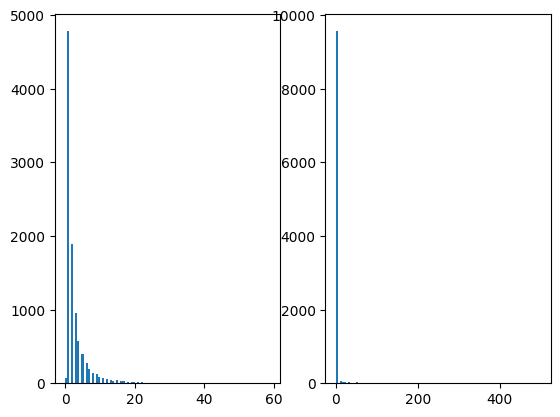

In [7]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
plot_degree_dist(doro)
# This shows that the vast majority of the nodes have no outgoing edges, and their perturbations therefore have no effect in the GRN
# ~5k sinks compared to 67 sources

## Compare KEGG, Doro, and Adamson:

In [8]:
kegg = pd.read_csv(f"Data/KEGG/kegg.topo",sep=" ")
print(kegg.head())
kegg_genes = set(list(kegg["Source"])+list(kegg["Target"]))

    Source Target  Type
0    GNA12  RASA2     1
1  RAPGEF2  RRAS2     1
2  RASGRF1  RRAS2     1
3  RASGRP1  RRAS2     1
4    RAP1A   BRAF     1


586 sources, 548 sinks


/tmp/ipykernel_22601/4188795243.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


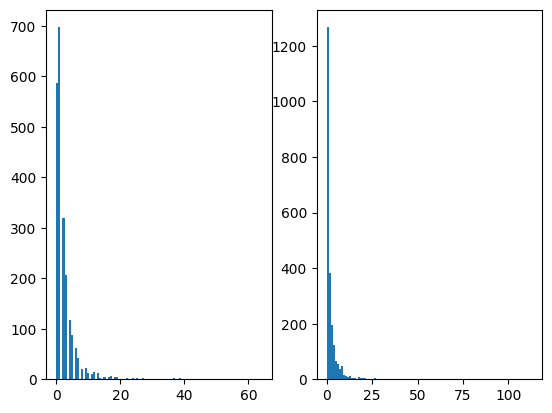

In [9]:
plot_degree_dist(kegg)
# sources and sinks about even at ~500

In [10]:
# Genes in KEGG but not in Doro/vice versa:

print(len(doro_genes-kegg_genes),len(kegg_genes-doro_genes),len(kegg_genes & doro_genes)) # 3940 vs 1042, overlap not great (1226)


8374 725 1543


In [11]:
keggoro = pd.concat([kegg,doro],ignore_index = True).drop_duplicates()
keggoro_genes = set(list(keggoro["Source"])+list(keggoro["Target"]))

In [ ]:
adamson_perts

{'AARS',
 'AMIGO3',
 'ARHGAP22',
 'ASCC3',
 'ATF4',
 'ATF6',
 'ATP5B',
 'C7orf26',
 'CAD',
 'CARS',
 'CCND3',
 'CHERP',
 'COPB1',
 'COPZ1',
 'DAD1',
 'DARS',
 'DDOST',
 'DDRGK1',
 'DERL2',
 'DHDDS',
 'DNAJC19',
 'EIF2AK3',
 'EIF2B2',
 'EIF2B3',
 'EIF2B4',
 'EIF2S1',
 'ERN1',
 'FARSB',
 'FECH',
 'GBF1',
 'GMPPB',
 'GNPNAT1',
 'HARS',
 'HSD17B12',
 'HSPA5',
 'HSPA9',
 'HYOU1',
 'IARS2',
 'IDH3A',
 'IER3IP1',
 'KCTD16',
 'MANF',
 'MARS',
 'MRGBP',
 'MRPL39',
 'MTHFD1',
 'NEDD8',
 'OST4',
 'P4HB',
 'PDIA6',
 'PPWD1',
 'PSMA1',
 'PSMD12',
 'PSMD4',
 'PTDSS1',
 'QARS',
 'SAMM50',
 'SARS',
 'SCYL1',
 'SEC61A1',
 'SEC61B',
 'SEC61G',
 'SEC63',
 'SEL1L',
 'SLC35B1',
 'SLC39A7',
 'SLMO2',
 'SOCS1',
 'SPCS2',
 'SPCS3',
 'SRP68',
 'SRP72',
 'SRPR',
 'SRPRB',
 'STT3A',
 'SYVN1',
 'TARS',
 'TELO2',
 'TIMM23',
 'TIMM44',
 'TMED10',
 'TMED2',
 'TMEM167A',
 'TTI1',
 'TTI2',
 'UFL1',
 'UFM1',
 'XBP1',
 'XRN1',
 'YIPF5',
 'ctrl'}

293 sources, 8660 sinks


/tmp/ipykernel_22601/4188795243.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


293 sources, 8660 sinks


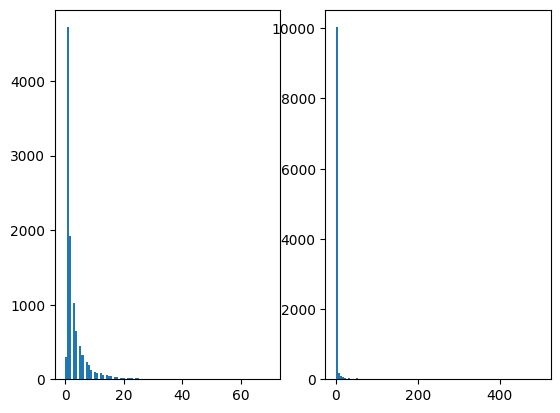

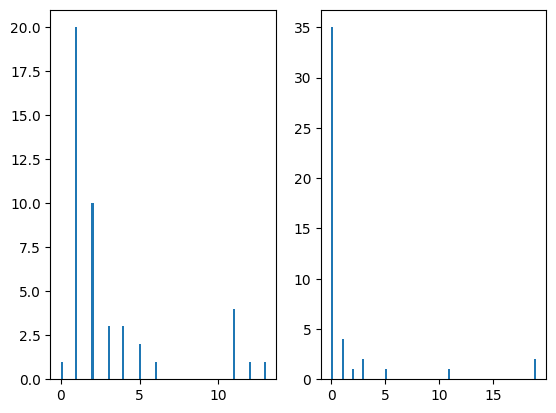

In [12]:
plot_degree_dist(keggoro) # Number of sinks slightly reduced
plot_degree_dist(keggoro,list(adamson_perts& keggoro_genes)) # Number of perts with outdeg=0 increased from 3 to ~10

In [13]:
len(adamson_perts & keggoro_genes)

46

In [15]:
norman_perts = set(list(norman_norm_data.obs["perturbation"]))
norman_dperts = list(set([tuple(dp.split("_")) for dp in list(norman_norm_data.obs["double_perturbation"].dropna())]))

In [22]:
a, b = norman_dperts[0]
print(norman_dperts[0])

('CBL', 'PTPN9')


In [30]:
dperts_common = []
for p1, p2 in norman_dperts:
    if (p1 in keggoro_genes) and (p2 in keggoro_genes):
        dperts_common.append(tuple([p1, p2]))

In [ ]:
print(len(doro_tfs & norman_perts),len(dperts_common),len(norman_perts & keggoro_genes))
# Surprisingly, a large amount of perts overlap, even only with ABCD
# Also, 22 perts are TFs

22 109 90


293 sources, 8660 sinks


/tmp/ipykernel_22601/4188795243.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


293 sources, 8660 sinks


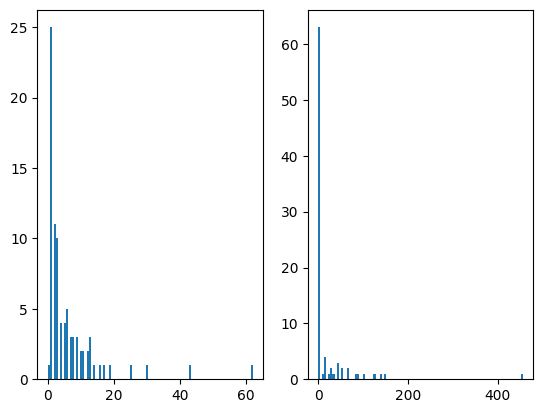

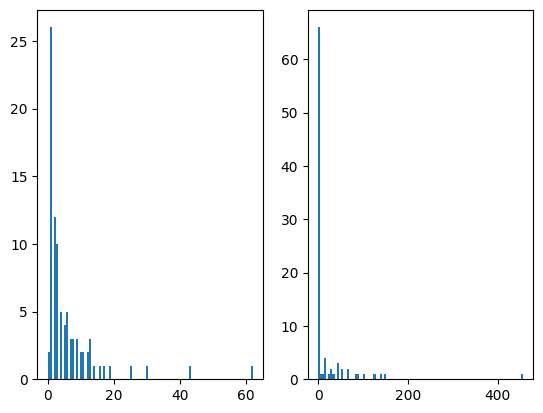

In [ ]:
plot_degree_dist(keggoro,list(norman_perts& doro_genes))
plot_degree_dist(keggoro,list(norman_perts& keggoro_genes))
# With Norman, there are ~25 single perturbations that are viable in keggoro, no big increase from doro

## Examine which RACIPE cluster is the closest to Adamson control data (for abc-TF2):

### Data Wrangle the GRiNS output:

In [2]:
simres_full = pd.read_parquet(f"Data/SimulResults_Racipe/dorothea_tf2_abc/001/dorothea_tf2_abc_steadystate_solutions_001.parquet")

In [ ]:
indices = [int(i) for i in np.linspace(0,simres_full.shape[0]-1,10000)]
simres_part = simres_full.iloc[indices]
goodcols = [col for col in simres_part.columns if "gk" not in col][:-7]
gene_cols = goodcols[:-7]
remaining_cols = goodcols[-7:]
gk_cols = [col for col in simres_part.columns if "gk" in col] # gk_cols good for state definition, other cols for count data
simres_part = simres_part.loc[:,gene_cols].to_numpy()
#simres_part = simres_part[]
#.to_numpy()

In [3]:
import anndata as ad
import scanpy as sc
import hdf5plugin
from scipy import sparse
def grins_to_h5ad():
    """
    Takes a .parquet file generated by GRiNS and turns it into an anndata object.

    Returns:
    --------
    grins_data : anndata
        An anndata object containing the grins steady state solutions.
    """
    sol_df = pd.read_parquet(f"Data/SimulResults_Racipe/dorothea_tf2_abc/001/dorothea_tf2_abc_steadystate_solutions_001.parquet")
    
    # Try out subset first

    gk_cols = [col for col in sol_df.columns if "gk_" in col]
    gene_cols = [col.replace("gk_", "") for col in sol_df.columns if "gk_" in col]
    sol_sparse = sparse.csr_matrix(sol_df.loc[:,gene_cols].values)
    grins_data = ad.AnnData(sol_sparse)
    grins_data.obs_names = [f"{sol_df.loc[:,"param_index"][i]}_{sol_df.loc[:,"ic_index"][i]}" for i in range(sol_df.shape[0])]
    grins_data.var_names = gene_cols

    return grins_data

In [ ]:
grins_data = grins_to_h5ad()

In [11]:
(adamson_norm_data.obs.columns)

Index(['perturbation', 'read count', 'UMI count', 'tissue_type', 'cell_line',
       'cancer', 'disease', 'perturbation_type', 'celltype', 'organism',
       'ncounts', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts',
       'CRISPRi', 'cell_type', 'condition', 'condition_name',
       'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier'],
      dtype='object')

In [ ]:
sc.pp.calculate_qc_metrics(grins_data,percent_top=[20],inplace=True)


In [20]:

norm_data = grins_data.copy()
sc.pp.normalize_total(norm_data, target_sum=None)

# Log1p transformation: 
norm_data.layers["normalized"] = norm_data.X.copy()
norm_data.layers["log1p"] = norm_data.layers["normalized"].copy()
sc.pp.log1p(norm_data, layer="log1p")
print("Finding highly variable genes...")
sc.pp.highly_variable_genes(norm_data,n_top_genes=5000, subset=True,layer="log1p")
print("Generating p values for DEGs, might take a long time...")
sc.tl.rank_genes_groups(norm_data, groupby="perturbation", layer="log1p",copy=False)

Finding highly variable genes...
Generating p values for DEGs, might take a long time...


KeyError: 'perturbation'

In [ ]:
grinsmeans = np.mean(simres_part,axis=0).squeeze()

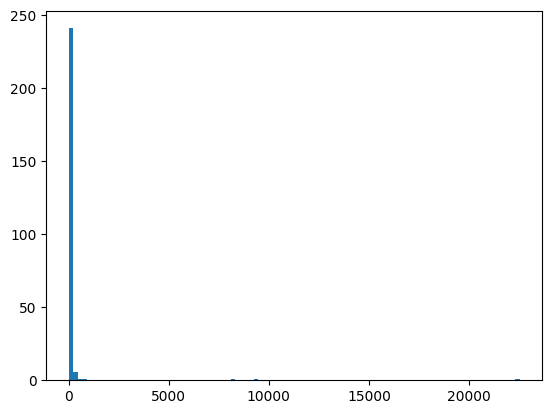

In [16]:
import matplotlib.pyplot as plt
plt.hist((grinsmeans),bins=100)
#plt.ylim(0,30)
plt.show()

In [ ]:
simres = pd.read_csv(f"Data/SimulResults/dorothea_tf2_abc/001/dorothea_tf2_abc_steadystate_state_counts_001.csv",sep="\t")
new_states = []
for i, row in simres.iterrows():
    cell = list(row["State"])
    if "n" in cell:
        simres.drop(i,inplace=True)
        continue
    gene_lvls = []
    for gene in cell[1:-1]:
        gene_lvls.append(bool(int(gene)))
    new_states.append(gene_lvls)

simres["State_Boolean"] = new_states

### Get Adamson for TFs:

In [ ]:
adamson_tf = adamson_norm_data[:,sorted(list(doro_tfs))]
adamson_tf = adamson_tf[adamson_norm_data.obs["perturbation"]=="ctrl"]
print(adamson_tf.shape)

KeyError: "Values [np.str_('ARID2'), np.str_('ARID3A'), np.str_('ARNT'), np.str_('ARNTL'), np.str_('ASCL1'), np.str_('ATF1'), np.str_('ATF2'), np.str_('ATF4'), np.str_('ATF7'), np.str_('BATF'), np.str_('BCL11A'), np.str_('BHLHE22'), np.str_('CDX2'), np.str_('CEBPA'), np.str_('CEBPD'), np.str_('CEBPG'), np.str_('CLOCK'), np.str_('CREB1'), np.str_('CREB3L1'), np.str_('CTCF'), np.str_('CUX1'), np.str_('DUX4'), np.str_('E2F1'), np.str_('E2F2'), np.str_('E2F3'), np.str_('E2F4'), np.str_('E2F5'), np.str_('E2F6'), np.str_('E2F7'), np.str_('EBF1'), np.str_('ELF1'), np.str_('ELF5'), np.str_('ELK1'), np.str_('ELK4'), np.str_('EOMES'), np.str_('ERG'), np.str_('ESR1'), np.str_('ESR2'), np.str_('ESRRA'), np.str_('ETV1'), np.str_('ETV4'), np.str_('FLI1'), np.str_('FOSL1'), np.str_('FOXA1'), np.str_('FOXJ2'), np.str_('FOXK2'), np.str_('FOXL2'), np.str_('FOXM1'), np.str_('FOXO1'), np.str_('FOXO3'), np.str_('FOXO4'), np.str_('FOXP1'), np.str_('FOXP2'), np.str_('GABPA'), np.str_('GATA4'), np.str_('GATA6

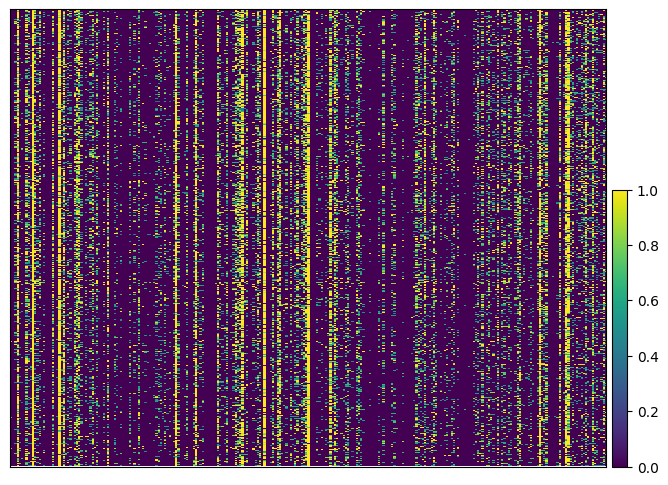

In [ ]:
sc.pl.heatmap(adamson_tf,layer="log1p",var_names = adamson_tf.var_names,groupby="perturbation",vmax=1) # Visualization of control heatmap

In [ ]:
ctrl_mean = np.asarray(np.mean(adamson_tf.layers["log1p"],axis=0)).squeeze()
discrete_ctrl_mean = list(map(lambda x: bool(np.heaviside(x-0.25,0)),ctrl_mean))
print(sum((discrete_ctrl_mean)),np.mean([sum(s) for s in simres["State_Boolean"]])) # With 0/1 threshold of 0.25, the mean of activated genes is about the same

66 69.16333166583291


In [ ]:
# Find distance
dist = []
for s in simres["State_Boolean"]:
    dist.append(sum([s[i]^discrete_ctrl_mean[i] for i in range(len(s))]))
simres["Dist_to_Adamson"] = dist

In [ ]:
print(np.min(simres["Dist_to_Adamson"]),len(discrete_ctrl_mean)) # Expected would be 135, but still not very good

92 271


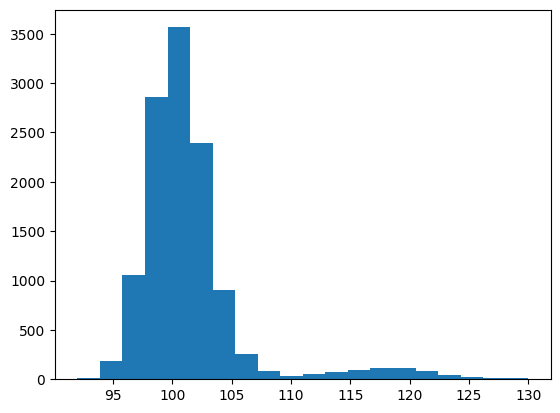

In [ ]:
import matplotlib.pyplot as plt

plt.hist(simres["Dist_to_Adamson"],bins=20) # Interesting distribution; is the order of genes really the same???
plt.show()